In [2]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt

In [3]:
if not os.path.exists('data'):
    with zipfile.ZipFile('data.zip', 'r') as z:
        z.extractall('.')

In [4]:
imputed = np.load('data/features.npz')
raw = np.load('data/non_imputed_data/features.npz')

# Drop the trailing dimension to make standard 2D matrices: (8128, 593, 1) -> (8128, 593)
imputed_data = imputed['data'].squeeze()
raw_data = raw['data'].squeeze()

languages = imputed_data.shape[0]
num_features = imputed_data.shape[1]

print(f"Loaded {languages} languages across {num_features} features.")

Loaded 8128 languages across 593 features.


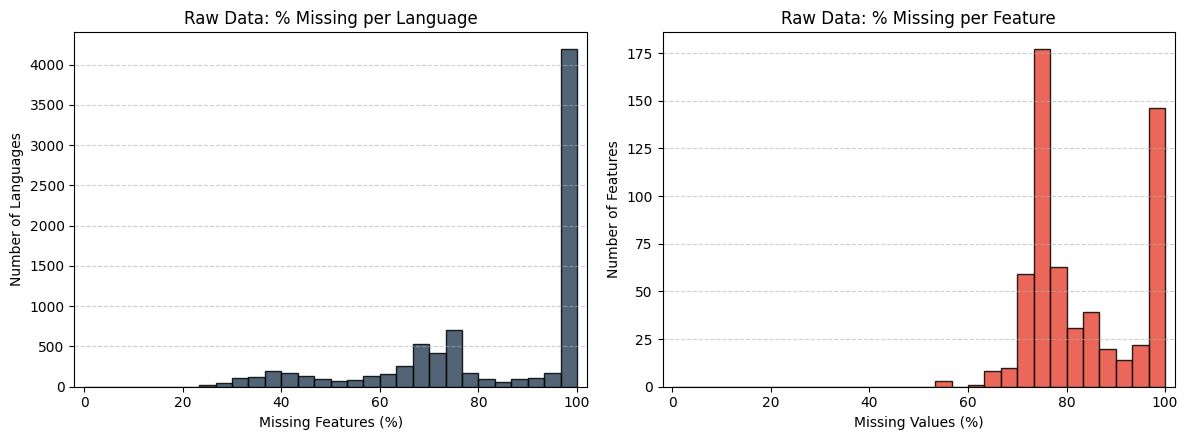

In [5]:
# Raw data missingness across languages (axis=1) and features (axis=0)
raw_lang_missing = np.mean(raw_data == -1, axis=1) * 100
raw_feat_missing = np.mean(raw_data == -1, axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True)

# % missing per language
axes[0].hist(raw_lang_missing, bins=30, range=(0, 100), color='#34495e', edgecolor='black', alpha=0.85)
axes[0].set_title('Raw Data: % Missing per Language')
axes[0].set_xlabel('Missing Features (%)')
axes[0].set_ylabel('Number of Languages')
axes[0].grid(axis='y', linestyle='--', alpha=0.6)

# % missing per feature
axes[1].hist(raw_feat_missing, bins=30, range=(0, 100), color='#e74c3c', edgecolor='black', alpha=0.85)
axes[1].set_title('Raw Data: % Missing per Feature')
axes[1].set_xlabel('Missing Values (%)')
axes[1].set_ylabel('Number of Features')
axes[1].grid(axis='y', linestyle='--', alpha=0.6)

plt.xlim(-2, 102)
plt.tight_layout()
plt.savefig('visualizations/milestone_2_eda/fig_per_missing_per_language.png', dpi=300, bbox_inches='tight')
plt.show()

**Raw Typological Sparsity:**
The left plot shows that over half the cataloged languages are missing more than 95% of their features. The right plot shows that every single feature is missing in at least 50% of languages, with most traits unrecorded around 75% of the time. Because missingness is severe across both rows and columns, naive row or column dropping would wipe out virtually the entire table.

In [7]:
# Missing rate per feature for imputed data
imputed_missing = np.mean(imputed_data == -1, axis=0) * 100

print(f"Average per feature missingness in Raw data:     {raw_feat_missing.mean():.1f}%")
print(f"Average per feature missingness in Imputed data: {imputed_missing.mean():.1f}%")



Average per feature missingness in Raw data:     82.9%
Average per feature missingness in Imputed data: 0.0%


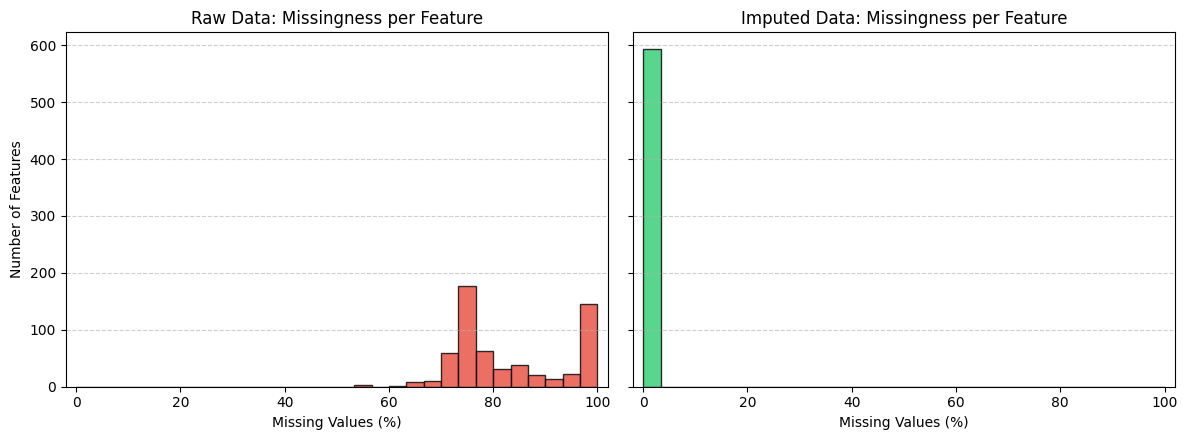

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True, sharey=True)

# Non-imputed raw histogram
axes[0].hist(raw_feat_missing, bins=30, range=(0, 100), color='#e74c3c', edgecolor='black', alpha=0.8)
axes[0].set_title('Raw Data: Missingness per Feature')
axes[0].set_xlabel('Missing Values (%)')
axes[0].set_ylabel('Number of Features')
axes[0].grid(axis='y', linestyle='--', alpha=0.6)

# Imputed histogram
axes[1].hist(imputed_missing, bins=30, range=(0, 100), color='#2ecc71', edgecolor='black', alpha=0.8)
axes[1].set_title('Imputed Data: Missingness per Feature')
axes[1].set_xlabel('Missing Values (%)')
axes[1].grid(axis='y', linestyle='--', alpha=0.6)

plt.xlim(-2, 102)
plt.tight_layout()
plt.savefig('visualizations/milestone_2_eda/fig_missingness_per_feature.png', dpi=300, bbox_inches='tight')
plt.show()

**Feature Imputation:**
In the raw data, features cluster around 75% and near 100% missingness. After running SoftImpute, missingness drops to 0.0% across all 593 features. This confirms all missing markers (`-1`) were filled, leaving a fully dense matrix.

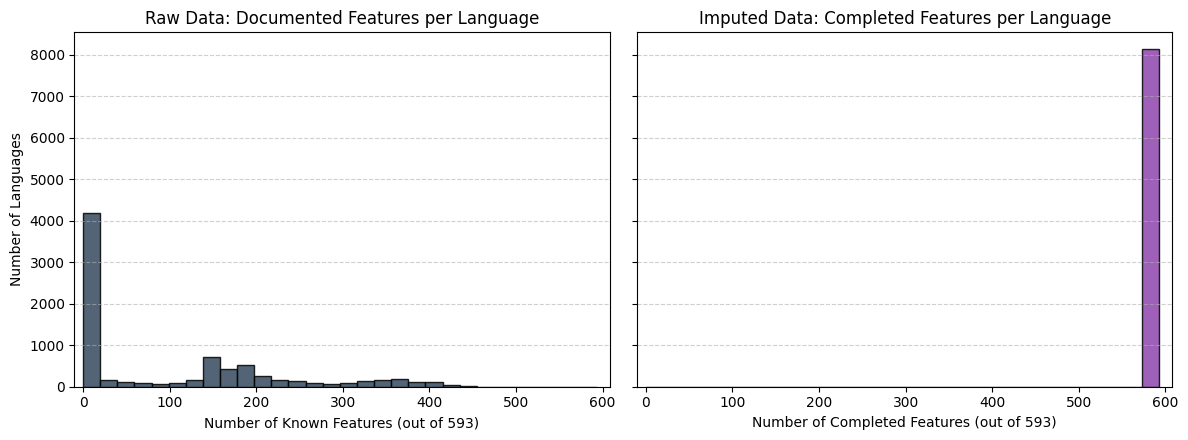

Raw data:     Median language has 11 / 593 features documented
Imputed data: Median language has 593 / 593 features completed


In [9]:
# Calculate how many features are known (not -1) for each language
raw_known_per_lang = np.sum(raw_data != -1, axis=1)
imputed_known_per_lang = np.sum(imputed_data != -1, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True, sharey=True)

# Raw Data Known Features per Language
axes[0].hist(raw_known_per_lang, bins=30, range=(0, num_features), color='#34495e', edgecolor='black', alpha=0.85)
axes[0].set_title('Raw Data: Documented Features per Language')
axes[0].set_xlabel(f'Number of Known Features (out of {num_features})')
axes[0].set_ylabel('Number of Languages')
axes[0].grid(axis='y', linestyle='--', alpha=0.6)

# Imputed Data Completed Features per Language
axes[1].hist(imputed_known_per_lang, bins=30, range=(0, num_features), color='#8e44ad', edgecolor='black', alpha=0.85)
axes[1].set_title('Imputed Data: Completed Features per Language')
axes[1].set_xlabel(f'Number of Completed Features (out of {num_features})')
axes[1].grid(axis='y', linestyle='--', alpha=0.6)

plt.xlim(-10, num_features + 15)
plt.tight_layout()
plt.savefig('visualizations/milestone_2_eda/fig_documented_features_per_language.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Raw data:     Median language has {np.median(raw_known_per_lang):.0f} / {num_features} features documented")
print(f"Imputed data: Median language has {np.median(imputed_known_per_lang):.0f} / {num_features} features completed")

**Language Coverage:**
Before imputation, thousands of languages had fewer than 20 documented traits out of 593. After imputation, every single language has a complete 593-dimensional vector. This allows our pipeline to retain under-documented languages rather than dropping them.

In [11]:
# Replace -1 with NaN so missing values do not bias the presence rate
raw_data_valid = np.where(raw_data == -1, np.nan, raw_data)
imputed_data_valid = np.where(imputed_data == -1, np.nan, imputed_data)

# Presence rate per feature
raw_presence = np.nanmean(raw_data_valid, axis=0) * 100
imputed_presence = np.nanmean(imputed_data_valid, axis=0) * 100

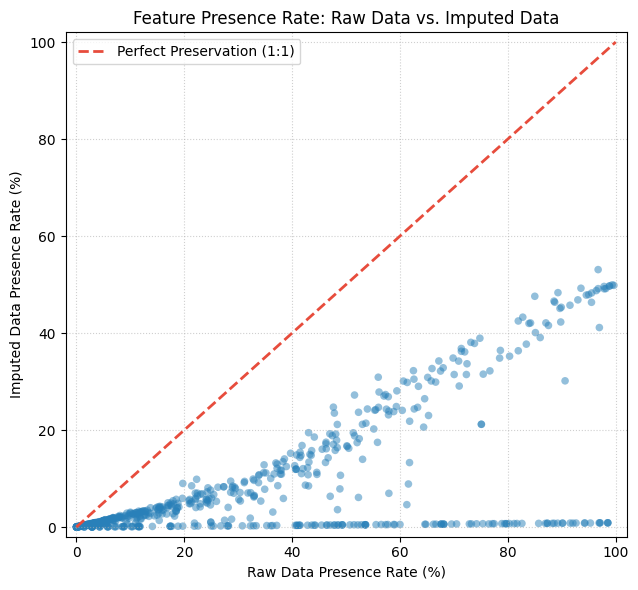

In [12]:
plt.figure(figsize=(6.5, 6))
plt.scatter(raw_presence, imputed_presence, alpha=0.5, edgecolors='none', color='#2980b9', s=30)
plt.plot([0, 100], [0, 100], '--', color='#e74c3c', linewidth=2, label='Perfect Preservation (1:1)')

plt.title('Feature Presence Rate: Raw Data vs. Imputed Data')
plt.xlabel('Raw Data Presence Rate (%)')
plt.ylabel('Imputed Data Presence Rate (%)')
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)

plt.xlim(-2, 102)
plt.ylim(-2, 102)
plt.tight_layout()
plt.savefig('visualizations/milestone_2_eda/fig_feature_presence_rate.png', dpi=300, bbox_inches='tight')
plt.show()

**Feature Presence Rate:**
All points sit on or below the 1:1 diagonal line, showing that imputation did not inflate feature presence. Instead of tracking the diagonal, the points spread out along a lower slope that caps near 50%, while a large cluster sits flat near 0%. Visually, this shows SoftImpute was conservative and leaned heavily toward filling missing entries with zeros.

Rare features (< 5%):       372
Common features (> 95%):    0
Usable features (5% - 95%): 221


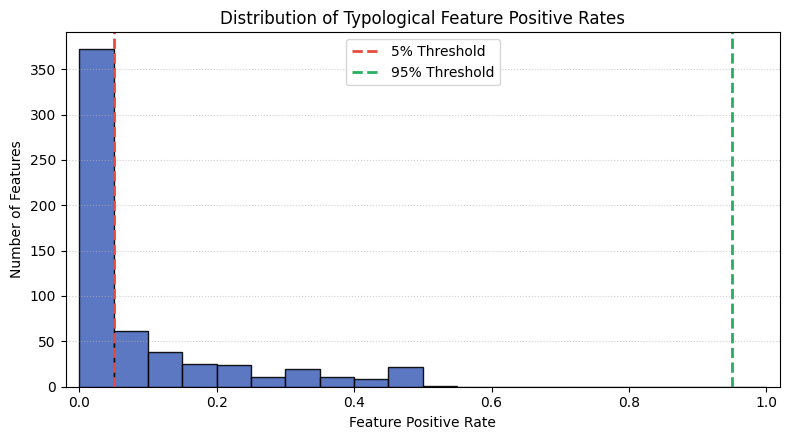

In [13]:
# Calculate positive rate across languages for imputed data
pos_rates = np.nanmean(imputed_data_valid, axis=0)

# Count rare, common and usable features
rare_features = np.sum(pos_rates < 0.05)
common_features = np.sum(pos_rates > 0.95)
usable_features = np.sum((pos_rates >= 0.05) & (pos_rates <= 0.95))

print(f"Rare features (< 5%):       {rare_features}")
print(f"Common features (> 95%):    {common_features}")
print(f"Usable features (5% - 95%): {usable_features}")


plt.figure(figsize=(8, 4.5))
plt.hist(pos_rates, bins=20, range=(0, 1), color='#4a69bd', edgecolor='black', alpha=0.9)

plt.axvline(x=0.05, color='#e74c3c', linestyle='--', linewidth=2, label='5% Threshold')
plt.axvline(x=0.95, color='#27ae60', linestyle='--', linewidth=2, label='95% Threshold')

plt.title('Distribution of Typological Feature Positive Rates')
plt.xlabel('Feature Positive Rate')
plt.ylabel('Number of Features')
plt.legend(loc='upper center')
plt.grid(axis='y', linestyle=':', alpha=0.6)

plt.xlim(-0.02, 1.02)
plt.tight_layout()
plt.savefig('visualizations/milestone_2_eda/fig_typ_feature_positive_rates.png', dpi=300, bbox_inches='tight')
plt.show()

**Feature Positive Rates:**
Most features are rarely present across languages: 372 features appear in less than 5% of languages, and 0 features appear in more than 95%. Filtering out these near-constant features leaves 221 usable features with sufficient variation for downstream modeling.